# Feature Importance & Feature Selection

## What is a Feature?

- A **feature (column)** is an input variable used by a machine learning model  
- Example:
  - Age, Salary, Pixels in an image, etc.

---

## Feature Selection

- Feature selection means:
  > Selecting the most important features and removing less useful ones

- Goal:
  - Improve model performance  
  - Reduce complexity  
  - Reduce overfitting  

---

## Feature Importance

- Feature importance is a technique used to:
  - Measure how important each feature is for prediction  

- It helps in:
  - Identifying useful features  
  - Performing feature selection  

 Therefore:
Feature Importance = A method for Feature Selection

---

## Example: MNIST Dataset

- Dataset contains handwritten digit images  
- Each image is represented as pixel values  

### Structure:
- ~42,000 images  
- ~784 features (pixels per image)  

---

### Key Observation

- Most important pixels are in the **center of the image**
- Pixels near edges:
  - Often contain no useful information  

---

## Role of Random Forest

- Random Forest can:
  - Automatically assign importance scores to each feature  
  - Identify which pixels (features) matter most  

---

## Why Feature Importance Matters

- Helps in selecting **best features**  
- Improves:
  - Model accuracy  
  - Training speed  

- Removes:
  - Irrelevant or noisy features  

---

## Interpretability

- Feature importance improves **model interpretability**

 It helps answer:
```text
Which features are influencing the model’s decision?

## finding feature Importance using random forest 

In [1]:
from sklearn.datasets import fetch_openml


mnist = fetch_openml('mnist_784', version=1)

X = mnist.data
y = mnist.target.astype(int)

In [3]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
from sklearn.model_selection import train_test_split

# using smaller subset for fast training 
X_small = X[:10000]
y_small = y[:10000]

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42
)

> random forest training

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
import numpy as np

importances = rf.feature_importances_

print("Total Features:", len(importances))

Total Features: 784


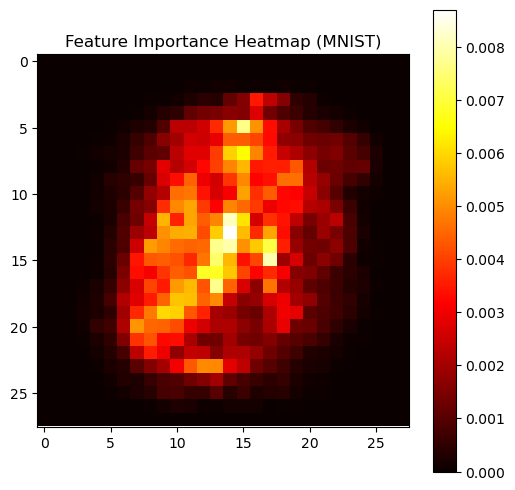

In [7]:
import matplotlib.pyplot as plt


importance_image = importances.reshape(28, 28)

plt.figure(figsize=(6,6))
plt.imshow(importance_image, cmap='hot')

plt.colorbar()
plt.title("Feature Importance Heatmap (MNIST)")

plt.show()

In [11]:
## top important pixels

# top 30
top_idx = np.argsort(importances)[-30:]

print("Top important pixel indices:", top_idx)

Top important pixel indices: [381 319 374 375 345 239 434 487 379 515 514 462 408 377 542 210 541 351
 211 461 460 409 433 155 405 489 406 437 350 378]


## but how these feature importance calculated ? mathematically

##### how we calculate feature importance using decision tree 

In [43]:
from sklearn.datasets import make_classification
import pandas as pd


X, y = make_classification(
    n_samples=20,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    random_state=42
)


cols = ['f1', 'f2', 'f3', 'f4', 'f5']
X = pd.DataFrame(X, columns=cols)

In [44]:
X.head()

,f1,f2,f3,f4,f5
0,0.322505,-0.161286,0.404051,2.316073,2.202960
1,0.569637,-0.192361,0.301547,0.644120,-3.359010
2,-1.629010,-1.415371,-0.420645,-0.142428,-1.956166
3,-0.365193,-0.392108,-1.463515,1.688127,-0.338513
4,0.182219,0.099651,-0.503476,1.632427,1.758926


In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


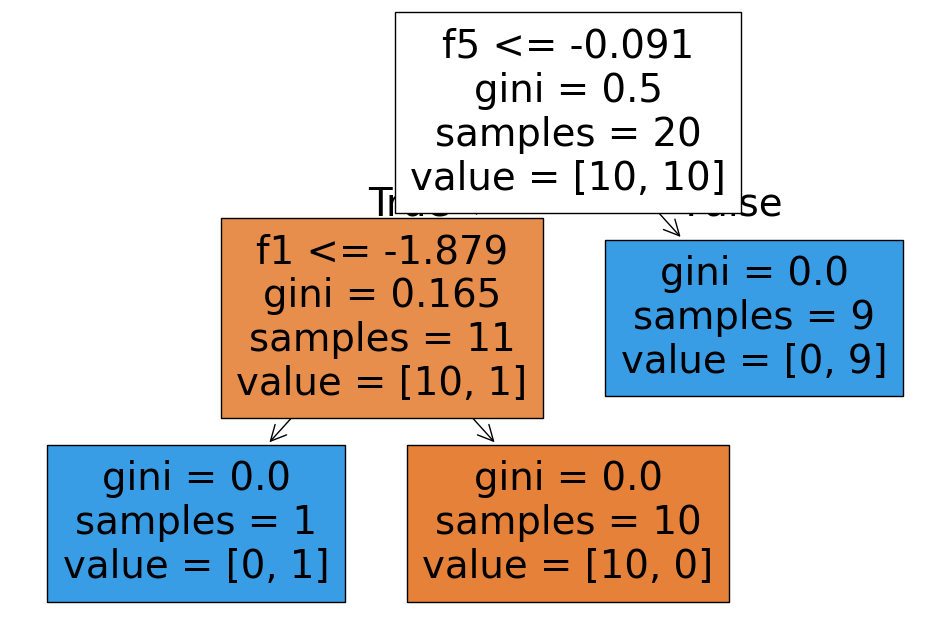

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=cols, filled=True)
plt.show()

In [47]:
import matplotlib.pyplot as plt

importances = dt.feature_importances_


feat_imp = pd.Series(importances, index=cols)


feat_imp = feat_imp.sort_values()

print(feat_imp)

f2    0.000000
f3    0.000000
f4    0.000000
f1    0.181818
f5    0.818182
dtype: float64


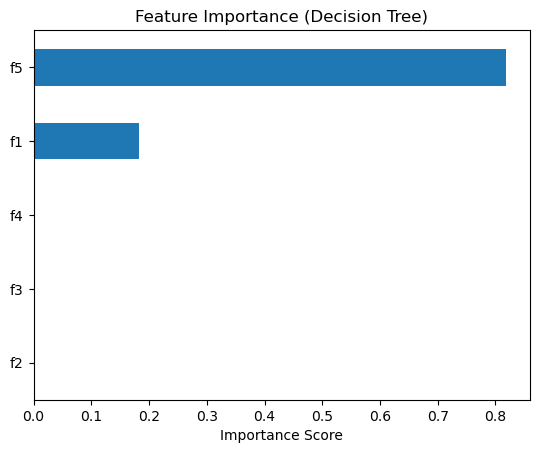

In [37]:
plt.figure()
feat_imp.plot(kind='barh')

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")

plt.show()

# Feature Importance Formula (Decision Tree)

## 1. Node Importance (ni)

$$
ni = \frac{N_t}{N} \left[ \text{impurity} - \left(\frac{N_{t_R}}{N_t} \cdot \text{right\_impurity}\right) - \left(\frac{N_{t_L}}{N_t} \cdot \text{left\_impurity}\right) \right]
$$

### Explanation

- $N$ → Total number of samples  
- $N_t$ → Number of samples at current node  
- $N_{t_R}$ → Samples in right child  
- $N_{t_L}$ → Samples in left child  

- impurity → impurity at current node  
- right_impurity → impurity after right split  
- left_impurity → impurity after left split  

---

### Intuition

- Measures how much impurity decreases after a split  
- More reduction → more important feature  

---

## 2. Feature Importance

$$
f_k = \frac{\sum_{j \in \text{nodes splitting on feature } k} ni_j}{\sum_{j \in \text{all nodes}} ni_j}
$$

---

### Explanation

- $f_k$ → importance of feature $k$  
- $ni_j$ → importance of node $j$  

---

### Intuition

- Sum importance of all nodes where feature $k$ is used  
- Normalize by total importance across all nodes  

---

## Final Understanding

- Step 1: Compute importance at each node  
- Step 2: Sum per feature  
- Step 3: Normalize  

---

## 

Feature importance is computed by summing impurity reduction contributed by each feature across all splits and normalizing it.

# feature importance in RandomForestclassifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=2, random_state=42)
rf.fit(X, y)

,n_estimators,2
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
import pandas as pd

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

print(feat_imp.sort_values(ascending=False))

f1    0.446677
f5    0.333581
f2    0.167659
f4    0.052083
f3    0.000000
dtype: float64


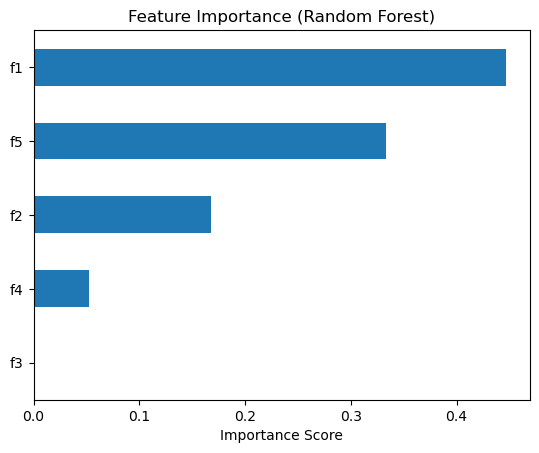

In [42]:
import matplotlib.pyplot as plt

feat_imp.sort_values().plot(kind='barh')

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

# Random Forest - Mathematical Formulation (Feature Importance)

## Given

- A Random Forest with $T$ trees  
- Each tree already computes feature importance using impurity reduction  

---

## 1. Feature Importance in One Tree

For a feature $k$ in tree $t$:

$$
FI_k^{(t)} = \sum_{\text{nodes } j \text{ where feature } k \text{ is used}} ni_j
$$

---

## 2. Normalization (per tree)

$$
FI_k^{(t)} = \frac{FI_k^{(t)}}{\sum_{\text{all nodes } j} ni_j}
$$

- Ensures total importance per tree sums to 1  

---

## 3. Random Forest Feature Importance

Final importance is the average across all trees:

$$
FI_k = \frac{1}{T} \sum_{t=1}^{T} FI_k^{(t)}
$$

---

## Final Interpretation

- Each tree gives importance based on impurity reduction  
- Random Forest:
  - Averages importance across all trees  
  - Reduces variance  
  - Produces more stable importance scores  

---

## Summary

Random Forest feature importance is the average of normalized impurity reductions contributed by a feature across all trees.

--------

# Warning: Impurity-Based Feature Importance Can Be Misleading

## What is the Warning?

Impurity-based feature importance (used in Decision Trees and Random Forest) can be **misleading for high-cardinality features**.

---

## What are High-Cardinality Features?

- Features with **many unique values**
- Examples:
  - ID columns  
  - Continuous variables with many distinct values  

---

## Why is this a Problem?

- Decision Trees tend to:
  - Prefer features that create **more splits**
  - High-cardinality features allow more possible split points  

👉 Result:
- These features may appear **artificially important**
- Even if they are **not truly useful**

---

## Key Issue

```text
More unique values ≠ More predictive power